In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [3]:
import json
import torch
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from src.cnn_lstm.cnn_lstm_v3 import CNNLSTMV3
from src.XAI.rise import RISE
from src.rwf2000 import RWF2000Dataset
from src.config import DATASET_ROOT
from src.config import CHECKPOINT_DIR
from src.XAI.plotting_functions import plot_saliency_grid
from scripts.common.get_device import get_available_device

experiment_root = CHECKPOINT_DIR / "CNN_LSTM_V4" / "final_systematic_search_2" / "h64_d0.35_wd2e-05_ls0.1"
device = get_available_device()

with open(experiment_root / "config.json", "r") as f:
    hyperparameters = json.load(f)

model = CNNLSTMV3(
    hidden_channels=hyperparameters["hidden_channels"],
    reduced_channels=hyperparameters["reduced_channels"],
    classifier_hidden_size=hyperparameters["classifier_hidden_size"],
    dropout=hyperparameters["dropout"],
    cnn_cutoff=hyperparameters["cnn_cutoff"],
    cnn_unfreeze_from=hyperparameters["cnn_unfreeze_from"], 
    pooling_mode=hyperparameters.get("pooling_mode", "double")
).to(device)

checkpoint = torch.load(experiment_root / "best_model.pt", map_location=device)

if "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.to(device)
model.eval()

dataset = RWF2000Dataset(
    DATASET_ROOT, 
    num_frames=hyperparameters["num_frames"], 
    input_mode=hyperparameters["input_mode"], 
    augment=False, 
    split="val", 
    return_rgb_frames=True
)

video_num = 7
video, label, rgb_frames = dataset[video_num]
video_batch = video.unsqueeze(0).to(device)
# [1, 32, 3, 224, 224]

label = label.item()

Using cuda:1 with 18.36 GB free


In [ ]:
rise = RISE(model, num_masks=16000, normalisation_mode="per_video", t=8)
rise.mask_probability = 0.15  # override the hardcoded default
heatmap = rise.generate_heatmap(video_batch, target_class=label)
 
prediction = model(video_batch).argmax(dim=1).item()
plot_saliency_grid(rgb_frames,heatmap,prediction=prediction)

In [ ]:
rise = RISE(model, num_masks=50000, normalisation_mode="per_video", t=8)
heatmap_2 = rise.generate_heatmap(video_batch, target_class=label)
 
prediction = model(video_batch).argmax(dim=1).item()
plot_saliency_grid(rgb_frames,heatmap,prediction=prediction)

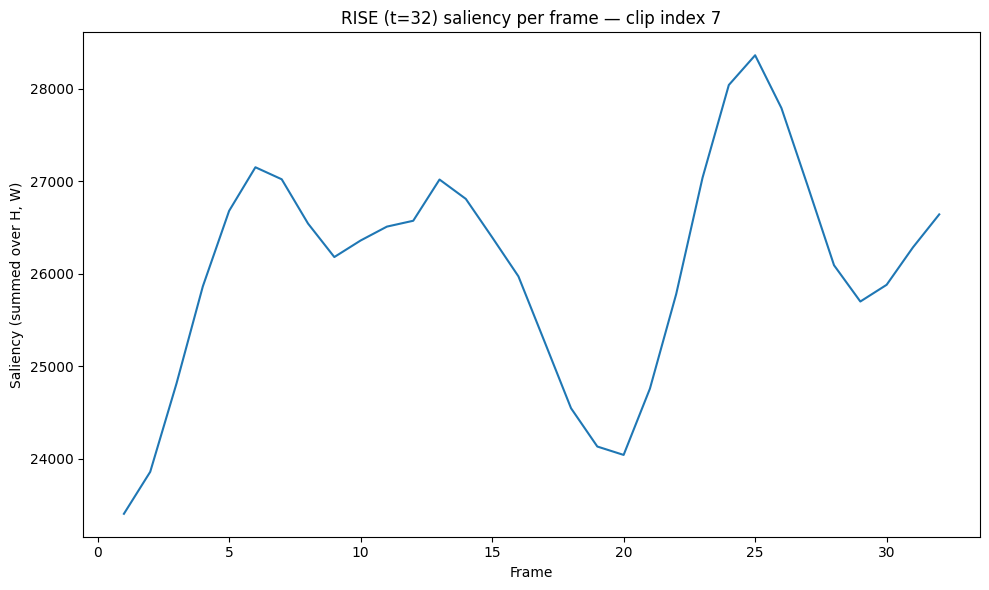

In [6]:
per_frame_totals = heatmap.squeeze(0).flatten(1).sum(dim=1)  # [32]

plt.figure(figsize=(10, 6))
plt.plot(range(1, 33), per_frame_totals.cpu().numpy())
plt.xlabel("Frame")
plt.ylabel("Saliency (summed over H, W)")
plt.title(f"RISE (t=32) saliency per frame — clip index {video_num}")
plt.tight_layout()
plt.show()

<Axes: xlabel='Fraction of locations perturbed', ylabel='Target class probability'>

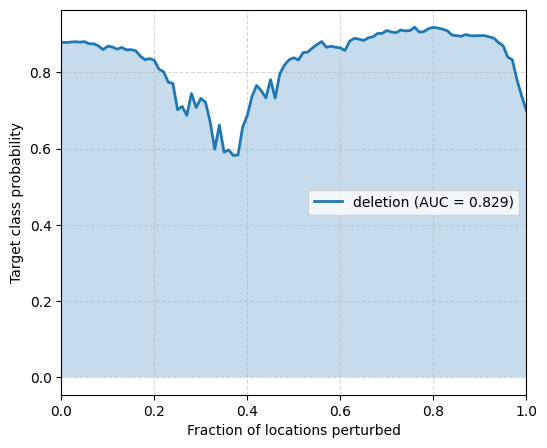

In [ ]:
from src.XAI.insertion_deletion_auc import AUC_TEST
auc_test = AUC_TEST(model=model,data_type="image")
fractions, scores, auc = auc_test.deletion(video_batch, saliency_map=heatmap)
AUC_TEST.plot_auc_curve(fractions, scores, auc, "deletion")